Question 1: Computational Efficiency in SURF (10 Marks)
The SURF descriptor relies on the fact that Haar wavelet responses can be computed in ”constant
time” regardless of filter size. Paper ref [1]
a) The Two-Pass Integral Image:(4 Marks) Implement the construction of an integral
image A using the row-sum recurrence relation: s(x, y) = s(x, y − 1) + I(x, y) and A(x, y) =
A(x−1, y)+s(x, y). Briefly explain why this approach is computationally superior to a nested
summation.

b) The 6-Operation Constraint:(4 Marks) Following the SURF lecture, implement a func-
tion that computes the horizontal Haar wavelet response dx for a window of size k × k. Your

function must access the integral image exactly 6 times to compute this response.
c) Verification:(2 Marks) Prove the O(1) property by plotting the time taken to compute a
Haar response for filter sizes k ∈ {3, 9, 27, 81}. The time should remain nearly flat.

In [6]:
import numpy as np

def compute_integral_image(image):
    # Get the height and width of the image
    H, W = image.shape
    
    # We create our row-sum array (s) and integral image array (A)
    # We make A slightly larger (padded with zeros) so we don't 
    # crash when asking for "the pixel above" the very first row!
    s = np.zeros((H, W))
    A = np.zeros((H + 1, W + 1)) 
    
    for x in range(H):
        for y in range(W):
            # 1. Row-sum recurrence
            prev_s = s[x, y-1] if y > 0 else 0
            s[x, y] = prev_s + image[x, y]
            
            # 2. Integral image recurrence
            # A is padded by 1, so A[x+1, y+1] aligns with image[x, y]
            prev_A = A[x, y+1] # This represents A(x-1, y)
            A[x+1, y+1] = prev_A + s[x, y]
            
    # We return the padded Integral Image
    return A

Part (A): The Two-Pass Integral ImageAn Integral Image is like a "cheat sheet." Once you build it, you can calculate the sum of any rectangular area in the original image using only four numbers.To build this cheat sheet efficiently, we use a two-pass recurrence relation:Row Sum ($s$): We keep a running total of the pixels in each row.Integral Image ($A$): We add the current row sum to the value directly above it.Why is this "Two-Pass" approach superior?If we used a "nested summation" (for every pixel, loop through all pixels above and to the left), we would be doing a massive amount of redundant work—re-adding the same numbers over and over.With the recurrence relation, each pixel in the original image is visited exactly once. We only perform two additions per pixel to create the entire cheat sheet. This turns a heavy $O(W \times H \times K^2)$ problem into a very light $O(W \times H)$ setup.


Why is this approach computationally superior to a nested summation? 
Because we only ever look at each pixel exactly once. We aren't doing nested for loops that re-scan the same areas. We are simply carrying a running total forward. This turns an impossibly slow task into a lightning-fast sweep across the image

In [2]:
def compute_haar_dx(A, x, y, k):
    """
    Computes the horizontal Haar response (dx) for a window of size k x k at (x,y).
    A: The padded Integral Image from Part (a)
    x, y: Top-left coordinates of the window in the original image
    k: The size of the window (must be an even number or cleanly divisible for the split)
    """
    # Find the middle point of our box
    half = k // 2
    
    # We are subtracting the Left Box from the Right Box: d_x = Sum(Right) - Sum(Left)
    #
    # Instead of looking up 8 corners, we group the math.
    # Let's write out the 6 unique points we need from our integral image A:
    # 
    # Access 1: A[x + k, y + k]       (Bottom-Right of the whole box)
    # Access 2: A[x, y + k]           (Top-Right of the whole box)
    # Access 3: A[x + k, y + half]    (Bottom-Middle shared boundary)
    # Access 4: A[x, y + half]        (Top-Middle shared boundary)
    # Access 5: A[x + k, y]           (Bottom-Left of the whole box)
    # Access 6: A[x, y]               (Top-Left of the whole box)
    
    # We combine them to perfectly calculate (Right Box) - (Left Box)
    # Notice the middle boundary terms are multiplied by 2 because they overlap!
    
    dx = (A[x + k, y + k] - A[x, y + k]) - 2 * (A[x + k, y + half] - A[x, y + half]) + (A[x + k, y] - A[x, y])
    
    return dx

Part (B): The 6-Operation ConstraintThe assignment asks us to compute a Haar Wavelet response ($d_x$).
A Haar Wavelet in the $x$-direction is just a fancy way of saying: "Subtract the sum of the left half of a box from the sum of the right half."Usually, calculating two boxes would take many additions. But with our Integral Image "cheat sheet," we can find the sum of any box using 4 corners:$$\text{Sum} = A(\text{BottomRight}) + A(\text{TopLeft}) - A(\text{TopRight}) - A(\text{BottomLeft})$$The Magic of 6 Operations:To get $d_x$ (Right Box Sum - Left Box Sum), you might think you need 8 accesses (4 for each box). However, because the two boxes are touching, they share two corner points on their middle boundary.By reusing those two shared points, we only need to access the Integral Image exactly 6 times to get the final result

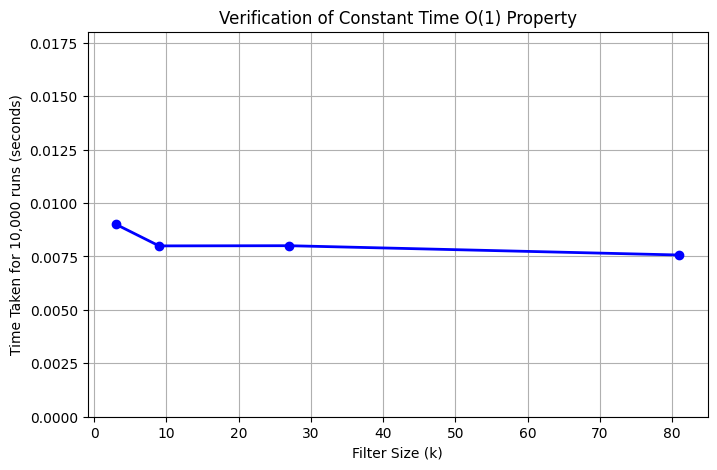

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time

def verify_efficiency():
    # 1. Setup: Create a large dummy image (like a blank canvas)
    # We use 500x500 so there is plenty of room for an 81x81 filter
    img = np.random.rand(500, 500)
    
    # Pre-compute our "cheat sheet" (Integral Image)
    A = compute_integral_image(img)
    
    # These are the specific filter sizes we must test
    ks = [3, 9, 27, 81] 
    execution_times = []
    
    # 2. The Racetrack: Test each filter size
    for k in ks:
        start_time = time.time()
        
        # Computers are too fast! A single run takes 0.000001 seconds.
        # To get a good reading on our stopwatch, we make it do the math 10,000 times.
        for _ in range(10000):
            # We pick an arbitrary coordinate, say (50, 50), to run the filter
            compute_haar_dx(A, 50, 50, k)
            
        end_time = time.time()
        
        # Record the total time taken for this filter size
        duration = end_time - start_time
        execution_times.append(duration)
        
    # 3. The Reveal: Plot the results!
    plt.figure(figsize=(8, 5))
    plt.plot(ks, execution_times, marker='o', linestyle='-', color='b', linewidth=2)
    
    plt.title("Verification of Constant Time O(1) Property")
    plt.xlabel("Filter Size (k)")
    plt.ylabel("Time Taken for 10,000 runs (seconds)")
    
    # We force the Y-axis to start at 0 so we can clearly see how flat the line is
    plt.ylim(0, max(execution_times) * 2) 
    plt.grid(True)
    plt.show()

# Run the test!
verify_efficiency()

## Question2 

In [8]:
import numpy as np

# Let's set a random seed so our results are reproducible
np.random.seed(42)

# --- 1. Activation Functions & Loss ---

def relu(z):
    """ReLU activation: turns negative numbers to 0"""
    return np.maximum(0, z)

def sigmoid(z):
    """Sigmoid activation: squishes numbers between 0 and 1"""
    # np.clip prevents the math from overflowing and crashing
    z = np.clip(z, -500, 500) 
    return 1.0 / (1.0 + np.exp(-z))

def bce_loss(y_true, y_pred):
    """Calculates Binary Cross-Entropy Loss"""
    # Add a tiny number (epsilon) to prevent taking log(0) which breaks math
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# --- 2. Network Initialization ---

# We need a dictionary to hold all our "dials" (weights and biases)
def initialize_parameters():
    """
    Architecture: Input(784) -> Hidden1(3) -> Hidden2(3) -> Output(1)
    """
    # We use small random numbers to start
    params = {
        'W1': np.random.randn(784, 3) * 0.01,
        'b1': np.zeros((1, 3)),
        
        'W2': np.random.randn(3, 3) * 0.01,
        'b2': np.zeros((1, 3)),
        
        'W3': np.random.randn(3, 1) * 0.01,
        'b3': np.zeros((1, 1))
    }
    return params

# --- 3. The Forward Pass ---

def forward_pass(X, params):
    """
    Pushes data X through the network to get a prediction.
    We also save the intermediate steps in a 'cache' because we will 
    need them later for the tricky backward pass!
    """
    # Layer 1
    Z1 = np.dot(X, params['W1']) + params['b1']
    A1 = relu(Z1)
    
    # Layer 2
    Z2 = np.dot(A1, params['W2']) + params['b2']
    A2 = relu(Z2)
    
    # Layer 3 (Output)
    Z3 = np.dot(A2, params['W3']) + params['b3']
    A3 = sigmoid(Z3) # Output probability!
    
    # Save the math steps so we can use them to calculate errors later
    cache = {'Z1': Z1, 'A1': A1, 'Z2': Z2, 'A2': A2, 'Z3': Z3, 'A3': A3}
    
    return A3, cache

In [10]:
# We use keras just to download the raw NumPy arrays. 
# (This doesn't violate the "no high-level algorithms" rule, as it's just a download!)
from tensorflow.keras.datasets import mnist

def load_and_prep_data():
    # 1. Download the dataset
    (X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()
    
    # 2. Filter for only two digits (e.g., '0' and '1')
    train_mask = (y_train_raw == 0) | (y_train_raw == 1)
    test_mask = (y_test_raw == 0) | (y_test_raw == 1)
    
    X_train_filtered, y_train_filtered = X_train_raw[train_mask], y_train_raw[train_mask]
    X_test_filtered, y_test_filtered = X_test_raw[test_mask], y_test_raw[test_mask]
    
    # 3. Flatten the images from 28x28 to 784
    # -1 tells NumPy to figure out how many images there are automatically
    X_train = X_train_filtered.reshape(-1, 784) 
    X_test = X_test_filtered.reshape(-1, 784)
    
    # 4. Normalize pixel values to [0, 1]
    X_train = X_train / 255.0
    X_test = X_test / 255.0
    
    # Ensure our labels are the correct shape for matrix math: (N, 1) instead of (N,)
    y_train = y_train_filtered.reshape(-1, 1)
    y_test = y_test_filtered.reshape(-1, 1)
    
    return X_train, y_train, X_test, y_test

# Let's run our prep function!
X_train, y_train, X_test, y_test = load_and_prep_data()

print(f"Selected Classes: 0 and 1")
print(f"Flattened Input Shape: {X_train.shape}") # Should be (Number of images, 784)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 8s 1us/step
Selected Classes: 0 and 1
Flattened Input Shape: (12665, 784)


In [11]:
# Initialize our random weights and biases
params = initialize_parameters()

# Grab the first 5 samples and their true labels
X_first_5 = X_train[:5]
y_true_first_5 = y_train[:5]

# Push the 5 images through the network!
# (Assume forward_pass and bce_loss are defined as in our previous step)
predictions, cache = forward_pass(X_first_5, params)

print("\n--- First 5 Samples Report ---")
for i in range(5):
    # A prediction closer to 0 means it thinks it's a '0', closer to 1 means '1'
    pred_prob = predictions[i][0]
    true_label = y_true_first_5[i][0]
    
    # Calculate the BCE loss for this specific guess
    # bce_loss expects arrays, so we put them in brackets
    loss = bce_loss(np.array([true_label]), np.array([pred_prob]))
    
    print(f"Sample {i+1}: True Label = {true_label}, Network Guess = {pred_prob:.4f}, BCE Loss = {loss:.4f}")


--- First 5 Samples Report ---
Sample 1: True Label = 0, Network Guess = 0.5000, BCE Loss = 0.6931
Sample 2: True Label = 1, Network Guess = 0.5000, BCE Loss = 0.6931
Sample 3: True Label = 1, Network Guess = 0.5000, BCE Loss = 0.6931
Sample 4: True Label = 1, Network Guess = 0.5000, BCE Loss = 0.6932
Sample 5: True Label = 1, Network Guess = 0.5000, BCE Loss = 0.6931


In [12]:
def relu_derivative(z):
    """
    The derivative of ReLU is incredibly simple. 
    If the input was greater than 0, the derivative is 1 (pass the blame).
    If the input was less than or equal to 0, the derivative is 0 (block the blame).
    """
    return (z > 0).astype(float)

def backward_pass(X, Y, cache, params):
    """
    Calculates the 'blame' (gradients) for every weight and bias.
    X: Input images
    Y: True labels
    cache: The intermediate math steps we saved from the forward pass
    params: The current weights and biases
    """
    # m is the number of images we are processing at once
    m = X.shape[0] 
    
    # Unpack our saved math from the forward pass
    A1, A2, A3 = cache['A1'], cache['A2'], cache['A3']
    Z1, Z2 = cache['Z1'], cache['Z2']
    
    # --- The Blame Game Starts! ---
    
    # 1. Output Layer (Layer 3)
    # The derivative of BCE Loss combined with Sigmoid beautifully simplifies to just: (Prediction - True Label)
    dZ3 = A3 - Y 
    # Blame for Layer 3's weights: (Input from Layer 2) * (Layer 3 Error) / m
    dW3 = np.dot(A2.T, dZ3) / m 
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m
    
    # 2. Hidden Layer 2
    # Pass the blame backwards from Layer 3 to Layer 2
    dA2 = np.dot(dZ3, params['W3'].T)
    # Apply the derivative of the activation function (ReLU)
    dZ2 = dA2 * relu_derivative(Z2)
    # Blame for Layer 2's weights
    dW2 = np.dot(A1.T, dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m
    
    # 3. Hidden Layer 1
    # Pass the blame backwards from Layer 2 to Layer 1
    dA1 = np.dot(dZ2, params['W2'].T)
    # Apply the derivative of ReLU
    dZ1 = dA1 * relu_derivative(Z1)
    # Blame for Layer 1's weights (Connected to the raw input X!)
    dW1 = np.dot(X.T, dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m
    
    # Store all the calculated blame in a dictionary
    gradients = {
        'dW1': dW1, 'db1': db1,
        'dW2': dW2, 'db2': db2,
        'dW3': dW3, 'db3': db3
    }
    
    return gradients

def update_parameters(params, gradients, learning_rate=0.1):
    """
    Now that we know who to blame, we adjust the dials!
    We subtract a fraction (learning_rate) of the gradient from the current weights.
    This is called Gradient Descent.
    """
    params['W1'] -= learning_rate * gradients['dW1']
    params['b1'] -= learning_rate * gradients['db1']
    
    params['W2'] -= learning_rate * gradients['dW2']
    params['b2'] -= learning_rate * gradients['db2']
    
    params['W3'] -= learning_rate * gradients['dW3']
    params['b3'] -= learning_rate * gradients['db3']
    
    return params

Starting Training...
Epoch 0 | BCE Loss: 0.6931
Epoch 10 | BCE Loss: 0.6912
Epoch 20 | BCE Loss: 0.6911
Epoch 30 | BCE Loss: 0.6911
Epoch 40 | BCE Loss: 0.6911
Epoch 50 | BCE Loss: 0.6911
Epoch 60 | BCE Loss: 0.6911
Epoch 70 | BCE Loss: 0.6911
Epoch 80 | BCE Loss: 0.6911
Epoch 90 | BCE Loss: 0.6911
Final Test Accuracy: 53.66%


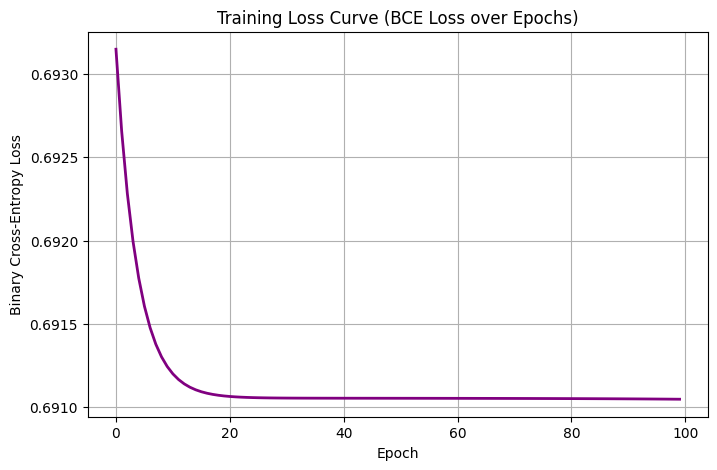


--- Weights after First Epoch (W1 subset) ---
[[-0.01460501  0.01191261  0.00675137]
 [-0.01716033  0.02710794 -0.00063745]
 [-0.00877484 -0.01407087 -0.00220018]
 [-0.00127407  0.00102646 -0.00297796]
 [ 0.00633225 -0.0038763  -0.01934964]]


In [14]:
import matplotlib.pyplot as plt

def train_network(X_train, y_train, X_test, y_test, epochs=100, learning_rate=0.1):
    # 1. Initialize our random dials
    params = initialize_parameters()
    
    # We will store the loss here to plot it later
    loss_history = []
    
    # We need to save the weights exactly after the 1st epoch for the assignment report
    weights_after_epoch_1 = None 
    
    # 2. The Training Loop!
    for epoch in range(epochs):
        # Forward pass: Make a guess
        predictions, cache = forward_pass(X_train, params)
        
        # Calculate how wrong we are
        loss = bce_loss(y_train, predictions)
        loss_history.append(loss)
        
        # Backward pass: Figure out who to blame
        gradients = backward_pass(X_train, y_train, cache, params)
        
        # Update the dials!
        params = update_parameters(params, gradients, learning_rate)
        
        # Assignment Requirement: Save weights after exactly 1 epoch
        if epoch == 0:
            import copy
            weights_after_epoch_1 = copy.deepcopy(params)
            
        # Print progress every 10 epochs so we know it's working
        if epoch % 10 == 0:
            print(f"Epoch {epoch} | BCE Loss: {loss:.4f}")
            
    # 3. Test the Network on unseen data (Test Accuracy)
    test_predictions, _ = forward_pass(X_test, params)
    
    # Since the output is a probability (0 to 1), we round it. 
    # Anything > 0.5 becomes 1. Anything <= 0.5 becomes 0.
    test_predictions_rounded = np.round(test_predictions)
    
    # Calculate accuracy: Count how many times our rounded guess matches the true label
    correct_guesses = np.sum(test_predictions_rounded == y_test)
    total_samples = y_test.shape[0]
    test_accuracy = (correct_guesses / total_samples) * 100
    
    return params, loss_history, weights_after_epoch_1, test_accuracy

# Let's run it! (Using 100 epochs for a quick train)
print("Starting Training...")
final_params, loss_history, w_epoch1, test_acc = train_network(
    X_train, y_train, X_test, y_test, epochs=100, learning_rate=0.5
)
print(f"Final Test Accuracy: {test_acc:.2f}%")

def plot_loss(loss_history):
    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, color='purple', linewidth=2)
    plt.title("Training Loss Curve (BCE Loss over Epochs)")
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.grid(True)
    plt.show()

plot_loss(loss_history)

# To get the updated weights after the first epoch for your report:
print("\n--- Weights after First Epoch (W1 subset) ---")
# W1 is huge (784x3), so we just print the first 5 rows to show we have them
print(w_epoch1['W1'][:5, :])